# Hidden Markov Model

In [11]:
from pathlib import Path
import sys

import pandas as pd

cwd = Path.cwd().resolve()
project_root = next(path for path in (cwd, *cwd.parents) if (path / "src" / "finance").exists())
src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from finance.data import GSPC_SYMBOL, get_gspc_prices


def format_history_label(period: str) -> str:
    unit_names = {"d": "day", "mo": "month", "y": "year"}
    for unit, unit_name in unit_names.items():
        if period.endswith(unit):
            value = period[: -len(unit)]
            if value.isdigit():
                suffix = "" if value == "1" else "s"
                return f"{value}-{unit_name}{suffix} history"
    return f"{period} history"


history_period = "20y"
history_label = format_history_label(history_period)
chart_title = f"{GSPC_SYMBOL} close history for HMM regime analysis ({history_label})"

gspc_rows = get_gspc_prices(period=history_period, provider="yfinance")
gspc = pd.DataFrame(gspc_rows)
gspc["date"] = pd.to_datetime(gspc["date"], utc=True)
gspc = gspc.sort_values("date").reset_index(drop=True)

analysis_start = gspc["date"].min()
analysis_end = gspc["date"].max()

gspc[["date", "open", "high", "low", "close", "volume"]].tail()

,date,open,high,low,close,volume
5027,2026-04-13 00:00:00+00:00,6806.470215,6887.000000,6790.020020,6886.240234,4785840000
5028,2026-04-14 00:00:00+00:00,6910.200195,6969.419922,6905.169922,6967.379883,5032380000
5029,2026-04-15 00:00:00+00:00,6978.169922,7026.240234,6967.129883,7022.950195,5278610000
5030,2026-04-16 00:00:00+00:00,7037.779785,7051.229980,7008.520020,7041.279785,5173650000
5031,2026-04-17 00:00:00+00:00,7074.549805,7147.520020,7074.549805,7126.060059,6145300000


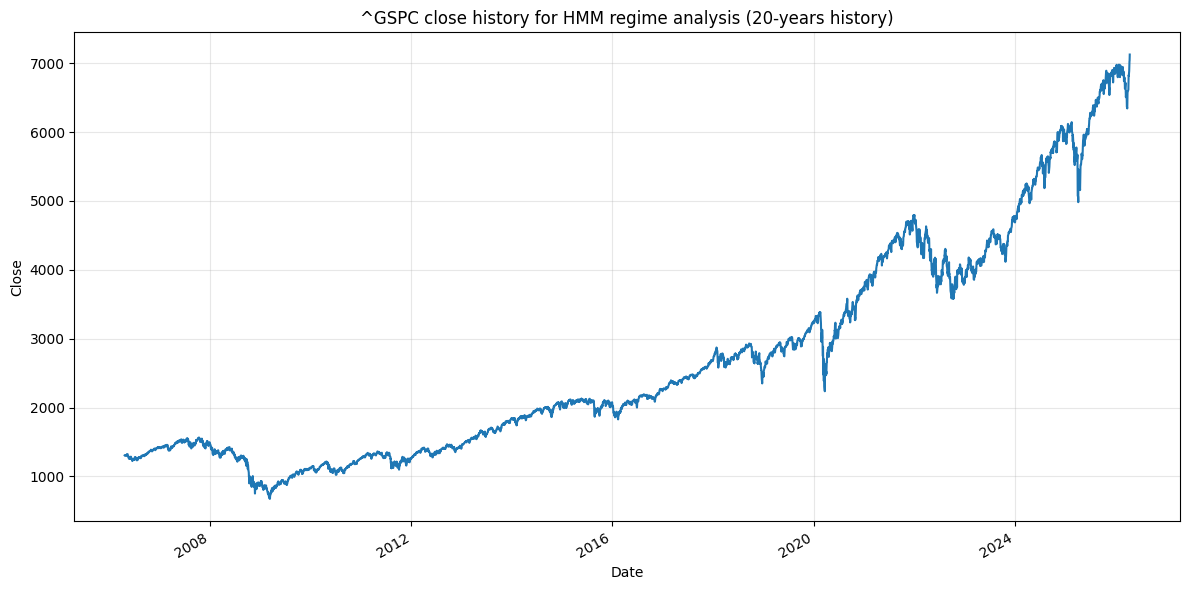

In [12]:
import matplotlib.pyplot as plt

ax = gspc.plot(
    x="date",
    y="close",
    figsize=(12, 6),
    linewidth=1.5,
    title=chart_title,
    legend=False,
)

ax.set_xlabel("Date")
ax.set_ylabel("Close")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
import numpy as np

vol_window = 20
feature_columns = ["log_return_1d", "realized_vol_20d", "volume_change_1d"]
observation_columns = [f"{column}_z" for column in feature_columns]

classification_data = gspc[
    ["date", "open", "high", "low", "close", "volume"]
] .copy()
classification_data["log_close"] = np.log(classification_data["close"])
classification_data["log_return_1d"] = classification_data["log_close"].diff()
classification_data["realized_vol_20d"] = (
    classification_data["log_return_1d"].rolling(vol_window).std() * np.sqrt(252)
)
classification_data["volume_change_1d"] = np.log1p(classification_data["volume"]).diff()

classification_data = classification_data.dropna(subset=feature_columns).reset_index(drop=True)

feature_means = classification_data[feature_columns].mean()
feature_stds = classification_data[feature_columns].std(ddof=0).replace(0.0, 1.0)
classification_data[observation_columns] = (
    classification_data[feature_columns].sub(feature_means).div(feature_stds).to_numpy()
)

hmm_observations = classification_data[observation_columns].to_numpy()

classification_data[
    ["date", *feature_columns, *observation_columns]
] .tail()

,date,log_return_1d,realized_vol_20d,volume_change_1d,log_return_1d_z,realized_vol_20d_z,volume_change_1d_z
5007,2026-04-13 00:00:00+00:00,0.010122,0.196072,0.085599,0.792317,0.305289,0.178125
5008,2026-04-14 00:00:00+00:00,0.011714,0.197062,0.050231,0.92128,0.314022,0.104374
5009,2026-04-15 00:00:00+00:00,0.007944,0.198204,0.04777,0.615919,0.324098,0.09924
5010,2026-04-16 00:00:00+00:00,0.002607,0.189056,-0.020084,0.183568,0.243383,-0.042255
5011,2026-04-17 00:00:00+00:00,0.011969,0.190282,0.172109,0.9419,0.254199,0.358523


In [14]:
from hmmlearn.hmm import GaussianHMM

n_states = 3

hmm_model = GaussianHMM(
    n_components=n_states,
    covariance_type="full",
    n_iter=500,
    random_state=42,
    min_covar=1e-4,
)
hmm_model.fit(hmm_observations)

classification_data["hidden_state"] = hmm_model.predict(hmm_observations)

state_summary = (
    classification_data.groupby("hidden_state")[feature_columns + ["close"]]
    .agg(["mean", "std", "count"])
    .round(4)
)

state_summary

log_return_1d               realized_vol_20d                \
                      mean     std count             mean     std count   
hidden_state                                                              
0                  -0.0002  0.0179  1972           0.2515  0.1343  1972   
1                   0.0007  0.0066  3039           0.1031  0.0285  3039   
2                   0.0087     NaN     1           0.1274     NaN     1   

             volume_change_1d                    close                   
                         mean     std count       mean        std count  
hidden_state                                                             
0                      0.0008  0.1781  1972  2415.0903  1465.9805  1972  
1                     -0.0075  0.4442  3039  2866.1909  1619.0132  3039  
2                     22.1458    <NA>     1  4151.2798        NaN     1

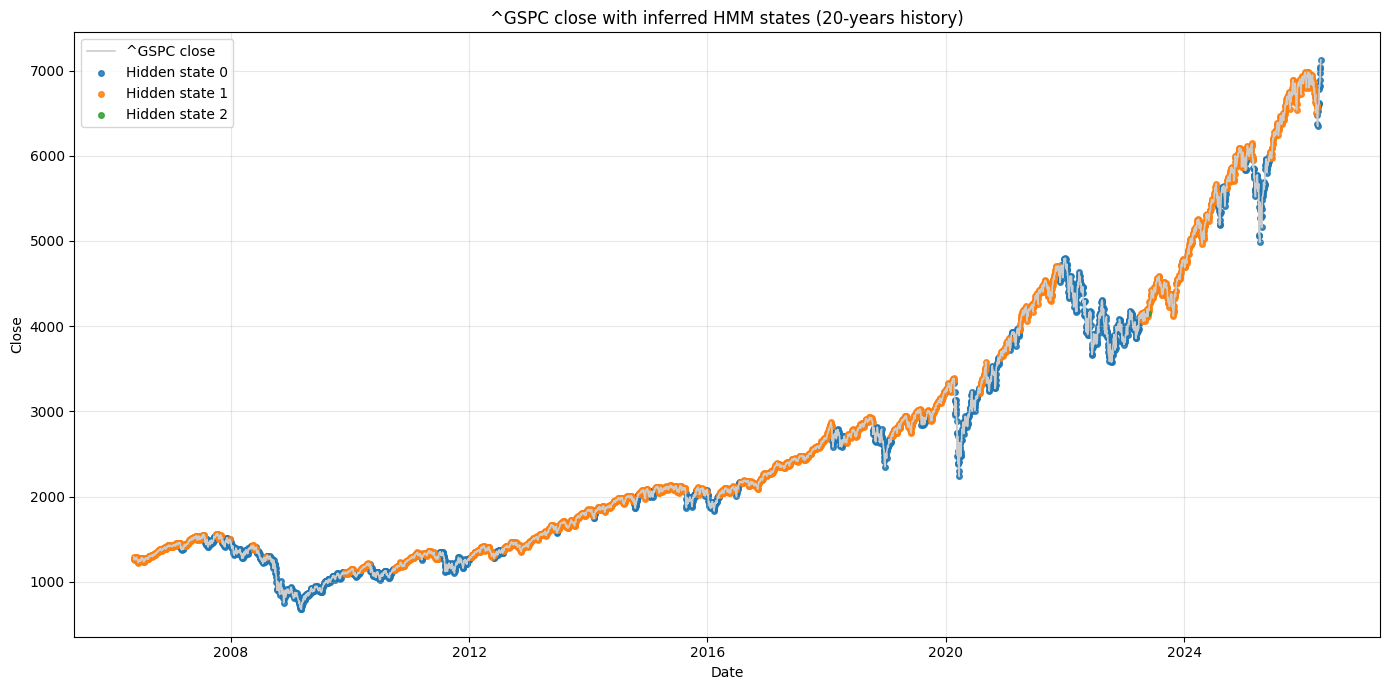

In [15]:
state_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
state_ids = sorted(classification_data["hidden_state"].unique())

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(
    classification_data["date"],
    classification_data["close"],
    color="0.80",
    linewidth=1.2,
    label=f"{GSPC_SYMBOL} close",
)

for index, state in enumerate(state_ids):
    state_mask = classification_data["hidden_state"] == state
    ax.scatter(
        classification_data.loc[state_mask, "date"],
        classification_data.loc[state_mask, "close"],
        s=16,
        alpha=0.85,
        color=state_colors[index % len(state_colors)],
        label=f"Hidden state {state}",
    )

ax.set_title(f"{GSPC_SYMBOL} close with inferred HMM states ({history_label})")
ax.set_xlabel("Date")
ax.set_ylabel("Close")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [16]:
import json

volatility_baseline = float(classification_data["realized_vol_20d"].median())

state_findings = []
for state in state_ids:
    state_frame = classification_data.loc[classification_data["hidden_state"] == state]
    mean_return = float(state_frame["log_return_1d"].mean())
    mean_volatility = float(state_frame["realized_vol_20d"].mean())
    mean_volume_change = float(state_frame["volume_change_1d"].mean())

    if mean_volatility > volatility_baseline:
        regime_hint = "high-volatility"
    elif mean_return >= 0:
        regime_hint = "calm-uptrend"
    else:
        regime_hint = "calm-downtrend"

    state_findings.append(
        {
            "state": int(state),
            "regime_hint": regime_hint,
            "observations": int(state_frame.shape[0]),
            "share_of_sample": round(float(state_frame.shape[0] / len(classification_data)), 4),
            "mean_log_return_1d": round(mean_return, 6),
            "mean_realized_vol_20d": round(mean_volatility, 6),
            "mean_volume_change_1d": round(mean_volume_change, 6),
            "first_date": state_frame["date"].min().date().isoformat(),
            "last_date": state_frame["date"].max().date().isoformat(),
        }
    )

hmm_findings = {
    "symbol": GSPC_SYMBOL,
    "history_period": history_period,
    "sample_start": classification_data["date"].min().date().isoformat(),
    "sample_end": classification_data["date"].max().date().isoformat(),
    "n_observations": int(len(classification_data)),
    "n_states": int(n_states),
    "observation_columns": observation_columns,
    "state_findings": state_findings,
    "transition_matrix": [[round(float(value), 6) for value in row] for row in hmm_model.transmat_],
    "start_probabilities": [round(float(value), 6) for value in hmm_model.startprob_],
}

print(json.dumps(hmm_findings, indent=2))

{
  "symbol": "^GSPC",
  "history_period": "20y",
  "sample_start": "2006-05-16",
  "sample_end": "2026-04-17",
  "n_observations": 5012,
  "n_states": 3,
  "observation_columns": [
    "log_return_1d_z",
    "realized_vol_20d_z",
    "volume_change_1d_z"
  ],
  "state_findings": [
    {
      "state": 0,
      "regime_hint": "high-volatility",
      "observations": 1972,
      "share_of_sample": 0.3935,
      "mean_log_return_1d": -0.000229,
      "mean_realized_vol_20d": 0.251469,
      "mean_volume_change_1d": 0.000779,
      "first_date": "2006-06-15",
      "last_date": "2026-04-17"
    },
    {
      "state": 1,
      "regime_hint": "calm-uptrend",
      "observations": 3039,
      "share_of_sample": 0.6063,
      "mean_log_return_1d": 0.000707,
      "mean_realized_vol_20d": 0.103089,
      "mean_volume_change_1d": -0.007497,
      "first_date": "2006-05-16",
      "last_date": "2026-03-25"
    },
    {
      "state": 2,
      "regime_hint": "calm-uptrend",
      "observations":